In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# PyTorch setup: Check for GPU (CUDA/MPS) or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Global Styling for Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

Using device: cuda


In [7]:
dataset_path = "../data/raw/mal/"

# Load the dataset
df_anime = pd.read_csv(f'{dataset_path}anime-dataset-2023.csv')

# Clean the 'Score' column
df_anime['Score'] = pd.to_numeric(df_anime['Score'], errors='coerce')

# Preview the data
df_anime[['Name', 'Score', 'Genres', 'Type', 'Members']].head()

,Name,Score,Genres,Type,Members
0,Cowboy Bebop,8.75,"Action, Award Winning, Sci-Fi",TV,1771505
1,Cowboy Bebop: Tengoku no Tobira,8.38,"Action, Sci-Fi",Movie,360978
2,Trigun,8.22,"Action, Adventure, Sci-Fi",TV,727252
3,Witch Hunter Robin,7.25,"Action, Drama, Mystery, Supernatural",TV,111931
4,Bouken Ou Beet,6.94,"Adventure, Fantasy, Supernatural",TV,15001


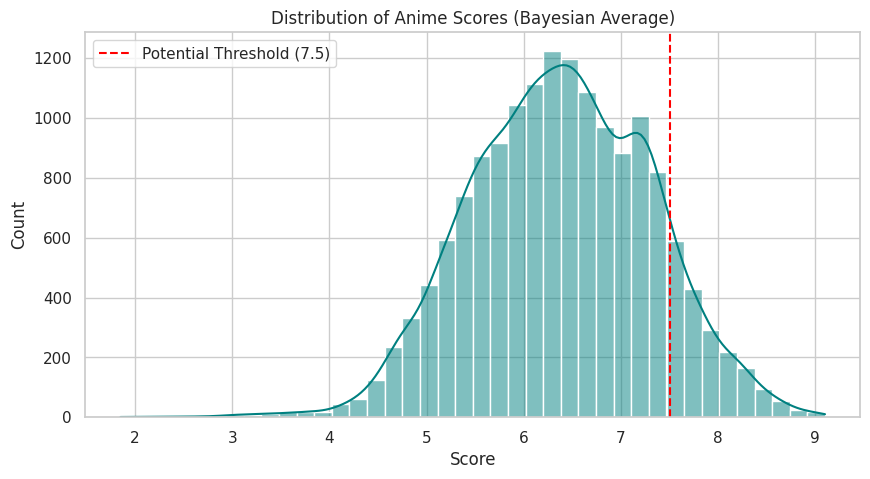

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_anime['Score'].dropna(), bins=40, kde=True, color="teal")
plt.axvline(x=7.5, color='red', linestyle='--', label='Potential Threshold (7.5)')
plt.title('Distribution of Anime Scores (Bayesian Average)')
plt.legend()
plt.show()

/tmp/ipykernel_66/3934463460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_anime, x='Type', y='Log_Members', palette="Set2")


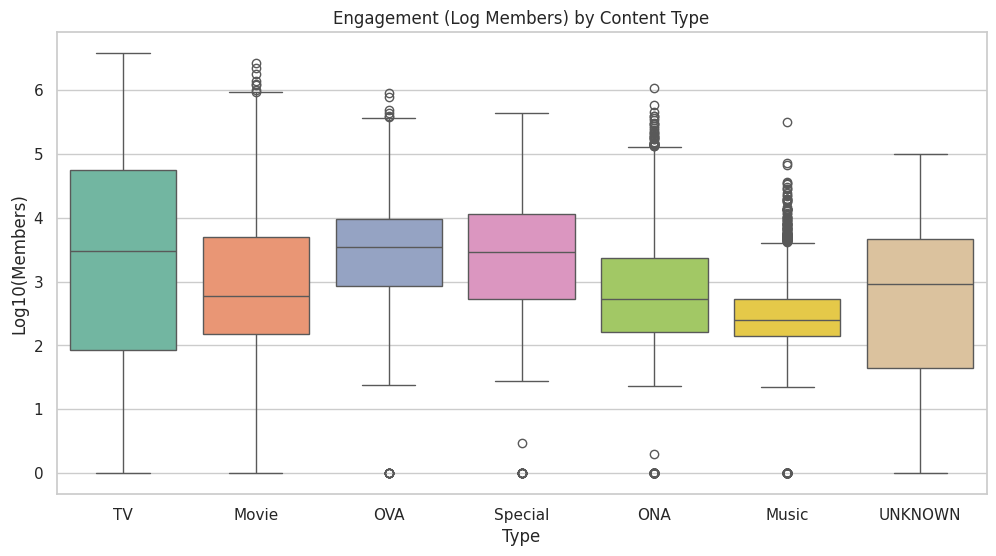

In [9]:
# Log scale for members because the range is massive (from 10 to 3 million)
df_anime['Log_Members'] = np.log10(df_anime['Members'] + 1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_anime, x='Type', y='Log_Members', palette="Set2")
plt.title('Engagement (Log Members) by Content Type')
plt.ylabel('Log10(Members)')
plt.show()

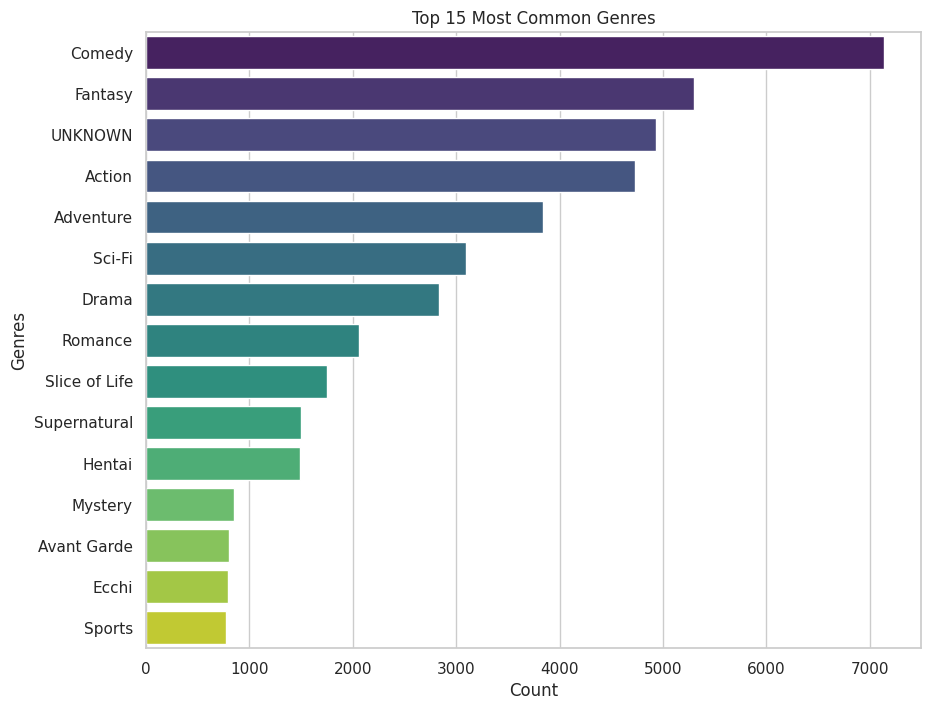

In [10]:
# Split and explode genres
genres_expanded = df_anime.assign(Genres=df_anime['Genres'].str.split(', ')).explode('Genres')

# Count top genres
top_genres = genres_expanded['Genres'].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False, palette="viridis")
plt.title('Top 15 Most Common Genres')
plt.xlabel('Count')
plt.show()